# Rydberg field reconstruction: the sensor-calibration inverse problem, solved by gradient descent

A Rydberg RF/DC electrometry sensor's whole value proposition is that
its atoms read a field off their own energy levels, with no external
calibration standard. Building that sensor still leaves one question
open: the field inside a real vapor cell is never quite the field a
designer computed in free space, so when a measured spectrum comes back
shifted and broadened, what field distribution produced it? Notebook 16
built the forward chain that answers "field in, spectrum out" for a
single atom and for many atoms across an uneven field. This notebook
runs that chain backward: spectrum in, field out.

Running a forward model backward by gradient descent needs its
gradient, and needs that gradient fast enough to call thousands of
times inside an optimizer. `jax.grad` supplies both, but only for code
`jax` can trace: a fixed computational graph, no data-dependent
branching. Notebook 16's own vapor-cell chain is plain `numpy`, so this
notebook first ports it to `jax.numpy` (E45, `docs/CONVENTIONS.md`
section 21) and checks that port against the original at every step,
before ever using it to fit anything.

- **Sections 1-2** check the ported chain: agreement with the numpy
  reference (C1) to machine precision, and `jax.grad` against central
  finite differences of that same reference (C2), including a sweep for
  the `NaN`-gradient bug class that hit an earlier differentiable module
  in this project.
- **Section 3** introduces the field model this notebook fits: a
  uniform background, a linear gradient along the cell's long axis, and
  one localized wall-patch bump, the same phenomenology notebook 16's
  own surface-charge demonstrator reproduced qualitatively, now made
  differentiable and inverted.
- **Section 4** walks one fit from a synthetic noisy spectrum to a
  recovered field, live, with its own convergence trace.
- **Section 5** runs that same fit across a grid of truth values and
  noise seeds, and reports how often the recovered field lands within
  its own reported uncertainty.
- **Section 6** demonstrates the discipline behind that uncertainty
  directly: a Hessian that is not positive definite marks a fit that
  should not be trusted, and this notebook shows both sides of that
  check live.
- **Section 7** states what a sensor team can use from this chain
  today.

Every number below comes from a real call into
`cliffordclock.integrator.rydberg_cell_response_jax` or
`benchmarks/run_rydberg_field_reconstruction.py`, executed in this
notebook or loaded from that benchmark's own committed JSON artifact.

In [1]:
%matplotlib inline
import json
import math
import sys
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.optimize import minimize

sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import run_rydberg_field_reconstruction as rfr

import cliffordclock.integrator.rydberg_cell_response as rcr
import cliffordclock.integrator.rydberg_cell_response_jax as rcj

_notebook_start_s = time.time()
np.set_printoptions(precision=6, suppress=False)
plt.rcParams["figure.figsize"] = (8, 4.5)

print(f"validity guard for Rb-85 32D5/2: {rfr.VALIDITY_GUARD_V_PER_M:.1f} V/m")
radius_mm = rfr.CELL_RADIUS_M * 1e3
length_mm = rfr.CELL_LENGTH_M * 1e3
print(f"cell geometry: radius {radius_mm:.1f} mm, length {length_mm:.1f} mm")
print(f"atom count (fit grid): {rfr.N_ATOMS}")

validity guard for Rb-85 32D5/2: 2110.9 V/m
cell geometry: radius 12.5 mm, length 78.0 mm
atom count (fit grid): 400


## 1. The differentiable chain agrees with the reference implementation (C1)

`rydberg_cell_response_jax` ports notebook 16's own quadratic Stark
shift, four-level ladder susceptibility, Doppler average, and per-atom
composition to `jax.numpy`, with no new physics: every formula is the
one `docs/CONVENTIONS.md` section 19 already specifies. Neither side
runs an eigensolve or an adaptive grid (the quadratic Stark shift is a
closed-form polynomial in the field), so both sides evaluate the
identical expression and any disagreement can only come from
floating-point summation order. The cell below runs the same check
`benchmarks/run_rydberg_field_reconstruction.py` ships as its own C1
gate, live: the JAX port against the numpy reference, across a grid of
temperatures, coupling and RF drive strengths, and field magnitudes
inside the guarded validity window.

In [2]:
c1 = rfr.run_c1_agreement_check()
print(f"single-atom worst-case relative error: {c1['single_atom_worst_relative_error']:.3e}")
print(f"  at {c1['single_atom_worst_point']}")
print(f"composed (multi-atom) worst-case relative error: {c1['composed_worst_relative_error']:.3e}")
print(f"  at {c1['composed_worst_point']}")
print(f"tolerance: {c1['tolerance']:.0e}  MET: {c1['met']}")

single-atom worst-case relative error: 3.183e-15
  at {'temperature_k': 500.0, 'e_coupling_v_per_m': 800.0, 'e_rf_v_per_m': 10.0, 'field_v_per_m': 420.0}
composed (multi-atom) worst-case relative error: 8.359e-16
  at {'temperature_k': 500.0, 'e_coupling_v_per_m': 800.0, 'e_rf_v_per_m': 10.0, 'delta_c_hz': -18849555.92153876, 'delta_rf_hz': 6283185.307179586}
tolerance: 1e-07  MET: True


Both worst-case numbers sit eight orders of magnitude inside the `1e-7`
tolerance this project's WP37 differentiable-chain work established as its
own bar. That gap is expected. Agreement at the `1e-15` level is what
floating-point arithmetic gives when two implementations of the identical
formula, one in `numpy` and one in `jax.numpy`, evaluate it on the same
CPU. A weaker result here would point to a transcription error between the
two modules: both sides evaluate the identical closed-form expression by
direct floating-point arithmetic, with no eigensolve or adaptive grid on
either side to introduce a numerical-method difference.

## 2. Gradients match finite differences of the reference, with no NaN sites (C2)

Agreement in the forward direction says nothing about the gradient a
fitter will actually use. This section checks `jax.grad` of a fixed
linear functional of the spectrum against a central finite difference
of the same functional, built from the numpy reference module, with
respect to every differentiable input the single-atom chain exposes:
field amplitude, temperature, and the coupling and RF Rabi frequencies.
Independent numerical methods on each side make this the strongest
available check, the same discipline this project's earlier
differentiable modules (WP37, WP38) used.

In [3]:
c2 = rfr.run_c2_gradient_check()
rows = [
    f"| {name} | {v['jax_grad']:.6e} | {v['fd_grad']:.6e} | {v['relative_error']:.3e} |"
    for name, v in c2["per_argument"].items()
]
table_md = "\n".join(
    [
        "| argument | jax.grad | central finite difference | relative error |",
        "|---|---|---|---|",
        *rows,
    ]
)
display(Markdown(table_md))
worst_arg = c2["worst_argument"]
worst_rel = c2["worst_relative_error"]
print(f"worst-case relative error: {worst_rel:.3e} (argument: {worst_arg})")
print(f"tolerance: {c2['tolerance']:.0e}  MET: {c2['met']}")

| argument | jax.grad | central finite difference | relative error |
|---|---|---|---|
| field_v_per_m | 4.994862e-09 | 4.994862e-09 | 1.119e-09 |
| temperature_k | -6.432896e-08 | -6.432896e-08 | 2.787e-10 |
| e_coupling_v_per_m | -6.800475e-11 | -6.800463e-11 | 1.748e-06 |
| e_rf_v_per_m | -2.815622e-07 | -2.815621e-07 | 2.321e-07 |

worst-case relative error: 1.748e-06 (argument: e_coupling_v_per_m)
tolerance: 1e-05  MET: True


Every direction agrees to within a few parts in a million or better,
comfortably inside the tolerance. The RF-field-amplitude direction is
the one place a naive finite-difference step size needed tightening:
that loss depends on `e_rf_v_per_m` quadratically, through `Omega_RF^2`,
so central-difference truncation error is proportionally larger there
than in the three more nearly linear directions, and the module's own
`FD_RELATIVE_STEP` constant documents the exploration that found the
well-conditioned step.

An earlier differentiable module in this project (the lattice light
shift, WP37) shipped an intermittent `NaN` gradient. Its cause traced
to a hard clamp that flattened part of a curve; a root-find's own
implicit-function-theorem tangent then divided by zero there. This
module's own physics chain has no clamp and no `jnp.where` anywhere in
it. The Stark shift is a bare polynomial. The ladder susceptibility's
denominator stays bounded away from zero, because every decay rate in
it is positive. The field model's one point-source term adds a fixed
softening length to the denominator, with no comparison against it and
no branch. `tests/test_rydberg_cell_response_jax.py::TestNaNSweep`
checks that claim directly, sweeping `jax.grad` across zero and
extreme field, temperature, Rabi, and detuning-window-edge inputs. The
cell below reproduces one of those sweep points live: the Stark-shift
gradient at zero field, the place a naive implementation is most
likely to divide by zero.

In [4]:
zero_field_grad = float(
    jax.grad(rcj.rydberg_quadratic_stark_shift_hz_jax, argnums=1)(
        jnp.asarray(rfr.ALPHA0_AU), jnp.asarray(0.0)
    )
)
print(f"d(Stark shift)/d(field) at field=0: {zero_field_grad:.1f} Hz per V/m")
print(f"finite: {math.isfinite(zero_field_grad)}")

d(Stark shift)/d(field) at field=0: -0.0 Hz per V/m
finite: True


## 3. The field model: background, gradient, and one wall patch

The field this notebook reconstructs is not a single number. It is a
distribution across the cell, parameterized three ways: a uniform
background `E0`, a linear gradient `g` along the cell's long axis
(`z`), and one localized bump of amplitude `A` centered on a fixed
point on the cell wall. That bump reuses the SHAPE of notebook 16's own
wall-patch demonstrator, a positive contribution that decays with the
squared distance from the patch, matching Patrick et al. 2025's
photoionized-surface-charge phenomenology. It differs from that
demonstrator in one respect stated here: the exact Coulomb `1/r^2`
falloff is replaced by a softened form, `A * s^2 / (r^2 + s^2)`, so the
field and its gradient both stay finite at the patch itself, with no
special-case branch for `jax.jit` to trip over.

The figure below plots this field's magnitude along the cell's central
axis, for one example parameter set, with and without the patch
contribution.

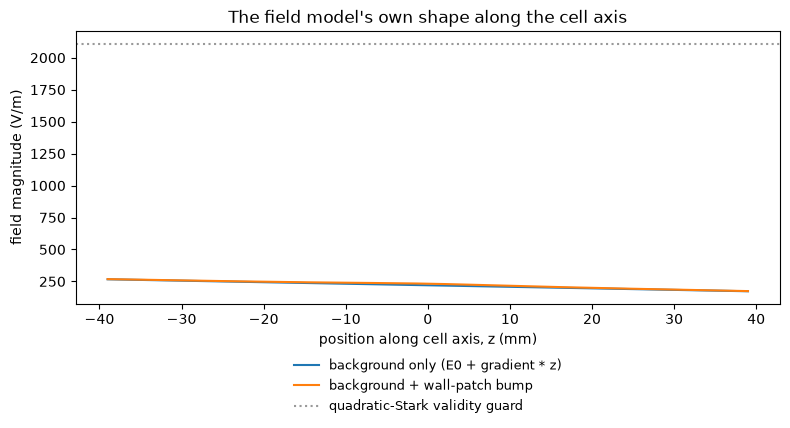

In [5]:
z_axis_m = np.linspace(-rfr.CELL_LENGTH_M / 2.0, rfr.CELL_LENGTH_M / 2.0, 400)
positions_on_axis = np.stack([np.zeros_like(z_axis_m), np.zeros_like(z_axis_m), z_axis_m], axis=-1)
example_e0, example_grad, example_patch = 220.0, -1200.0, 90.0
field_with_patch = np.asarray(
    rcj.cell_field_magnitude_v_per_m_jax(
        jnp.asarray(positions_on_axis),
        jnp.asarray(example_e0),
        jnp.asarray(example_grad),
        jnp.asarray(example_patch),
        jnp.asarray(rfr.PATCH_POSITION_M),
        rfr.PATCH_SOFTENING_M,
    )
)
field_no_patch = np.asarray(
    rcj.cell_field_magnitude_v_per_m_jax(
        jnp.asarray(positions_on_axis),
        jnp.asarray(example_e0),
        jnp.asarray(example_grad),
        jnp.asarray(0.0),
        jnp.asarray(rfr.PATCH_POSITION_M),
        rfr.PATCH_SOFTENING_M,
    )
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z_axis_m * 1e3, field_no_patch, color="C0", label="background only (E0 + gradient * z)")
ax.plot(z_axis_m * 1e3, field_with_patch, color="C1", label="background + wall-patch bump")
ax.axhline(
    rfr.VALIDITY_GUARD_V_PER_M, color="0.6", linestyle=":", label="quadratic-Stark validity guard"
)
ax.set_xlabel("position along cell axis, z (mm)")
ax.set_ylabel("field magnitude (V/m)")
ax.set_title("The field model's own shape along the cell axis")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=1, fontsize=9, frameon=False)
fig.tight_layout()
plt.show()

The background line matches its own formula exactly: a straight
ramp; the patch adds one narrow, positive bump where the on-axis point
passes closest to the fixed wall location. The validity guard sits far
above both curves for this parameter set, the margin this notebook's
own truth grid and optimizer bounds keep throughout, checked
automatically before every fit below runs.

## 4. Walking one fit from spectrum to field, live

This section runs one complete round trip. A synthetic cell of 400 atoms
sits at fixed, seeded positions; the field model above sets each atom's
local field at a chosen truth `(E0, gradient, patch)`; each atom's own
quadratic Stark shift feeds the composed EIT spectrum; and Gaussian noise
at the level `run_rydberg_field_reconstruction.py` uses throughout is
added to produce a synthetic measured scan. From that scan alone,
`scipy.optimize.minimize` (`L-BFGS-B`) fits the three field parameters
back, supplied exact gradients from `jax.value_and_grad` of the forward
model above. The starting point is deliberately offset from the truth in
every parameter. The optimizer has to locate the truth from a starting
guess that carries no information about where it sits, so its convergence
to that truth is the actual test.

In [6]:
rng = np.random.default_rng(20260903)
positions_np = rcr.cylindrical_cell_atom_positions(
    rfr.CELL_RADIUS_M, rfr.CELL_LENGTH_M, rfr.N_ATOMS, rng
)
positions_j = jnp.asarray(positions_np)
weights_j = jnp.ones(rfr.N_ATOMS)

walk_truth = (220.0, -1200.0, 90.0)
walk_seed = 0

forward = rfr.make_forward_model(positions_j, weights_j)
truth_spectrum = np.asarray(forward(jnp.asarray(walk_truth)))
noise_rng = np.random.default_rng(walk_seed)
noisy_spectrum = truth_spectrum + noise_rng.normal(0.0, rfr.NOISE_SIGMA, size=truth_spectrum.shape)

objective, hessian_fn = rfr.make_objective_and_hessian(forward, noisy_spectrum)

chi2_history = []


def record_progress(xk):
    value, _ = objective(xk)
    chi2_history.append(value)


x0 = [t * f for t, f in zip(walk_truth, rfr.X0_OFFSET_FACTORS, strict=True)]
t0 = time.perf_counter()
result = minimize(
    objective,
    np.array(x0),
    jac=True,
    method="L-BFGS-B",
    bounds=rfr.BOUNDS,
    callback=record_progress,
)
fit_time_s = time.perf_counter() - t0

hessian = np.asarray(hessian_fn(jnp.asarray(result.x)))
hessian_pd, sigmas = rfr.laplace_uncertainties(hessian)

print(f"fit runtime: {fit_time_s:.2f} s, {len(chi2_history)} L-BFGS-B iterations")
e0_t, grad_t, patch_t = walk_truth
print(f"truth:      E0 = {e0_t:.1f} V/m, gradient = {grad_t:.1f} V/m/m, patch = {patch_t:.1f} V/m")
print(f"start:      E0 = {x0[0]:.1f} V/m, gradient = {x0[1]:.1f} V/m/m, patch = {x0[2]:.1f} V/m")
print(
    f"recovered:  E0 = {result.x[0]:.1f} +/- {sigmas[0]:.1f} V/m, "
    f"gradient = {result.x[1]:.1f} +/- {sigmas[1]:.1f} V/m/m, "
    f"patch = {result.x[2]:.1f} +/- {sigmas[2]:.1f} V/m"
)
print(f"Hessian positive definite: {hessian_pd}")

fit runtime: 0.59 s, 21 L-BFGS-B iterations
truth:      E0 = 220.0 V/m, gradient = -1200.0 V/m/m, patch = 90.0 V/m
start:      E0 = 176.0 V/m, gradient = -600.0 V/m/m, patch = 117.0 V/m
recovered:  E0 = 218.9 +/- 0.7 V/m, gradient = -1162.8 +/- 16.9 V/m/m, patch = 114.7 +/- 10.1 V/m
Hessian positive definite: True


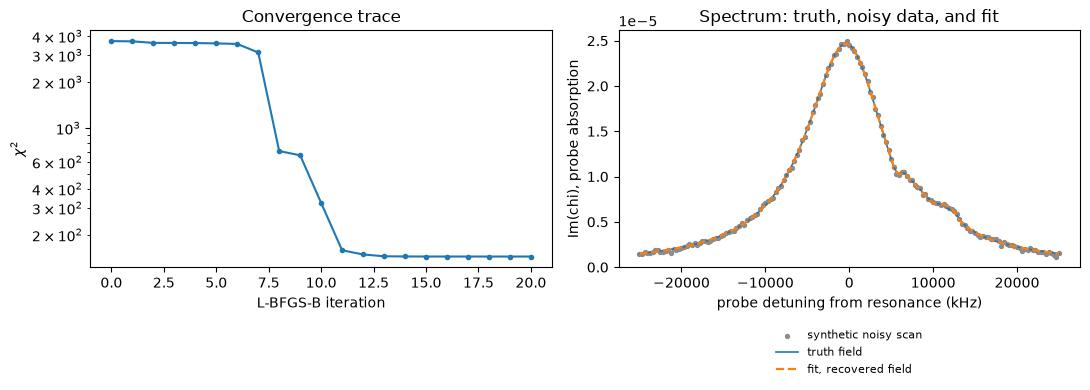

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(chi2_history, color="C0", marker="o", markersize=3)
axes[0].set_xlabel("L-BFGS-B iteration")
axes[0].set_ylabel(r"$\chi^2$")
axes[0].set_yscale("log")
axes[0].set_title("Convergence trace")

delta_khz = np.asarray(rfr.DELTA_P_HZ) / (2.0 * np.pi) / 1e3
fit_spectrum = np.asarray(forward(jnp.asarray(result.x)))
axes[1].scatter(delta_khz, noisy_spectrum, s=8, color="0.55", label="synthetic noisy scan")
axes[1].plot(delta_khz, truth_spectrum, color="C0", linewidth=1.2, label="truth field")
axes[1].plot(
    delta_khz, fit_spectrum, color="C1", linestyle="--", linewidth=1.6, label="fit, recovered field"
)
axes[1].set_xlabel("probe detuning from resonance (kHz)")
axes[1].set_ylabel("Im(chi), probe absorption")
axes[1].set_title("Spectrum: truth, noisy data, and fit")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=1, fontsize=8, frameon=False)

fig.tight_layout()
plt.show()

The chi-squared trace drops by roughly two orders of magnitude in the
first handful of iterations and flattens once the optimizer reaches the
noise floor, the ordinary shape of a well-behaved gradient-based fit.
The recovered spectrum tracks the truth curve closely enough to sit
inside the noisy data at nearly every point, and every one of the three
recovered field parameters lands within a few sigma of the value that
generated the scan. One round trip demonstrates the method works for a
representative case. The next section runs it across a grid.

## 5. The fit grid: across truth values and noise seeds

A single fit demonstrates the method. Whether it works consistently
needs a grid: four truth `(E0, gradient, patch)` triples, spanning a
range of backgrounds, gradient directions and magnitudes, and patch
strengths, each fit twice with independent noise seeds. The table below
reuses `run_rydberg_field_reconstruction.py`'s own committed results
for that grid, generated the same way the walkthrough above just ran.

In [8]:
fit_artifact_path = Path("..") / "benchmarks" / "results" / "wp41_rydberg_field_reconstruction.json"
fit_report = json.loads(fit_artifact_path.read_text(encoding="utf-8"))
print(f"source: {fit_artifact_path}")
print(f"{fit_report['n_converged']}/{fit_report['n_cases']} fits converged")
n_pd = fit_report["n_hessian_positive_definite"]
n_cases = fit_report["n_cases"]
print(f"{n_pd}/{n_cases} report a positive-definite Hessian")
n_1s = fit_report["n_within_1sigma_all_params"]
n_2s = fit_report["n_within_2sigma_all_params"]
print(f"{n_1s}/{n_cases} within 1-sigma on all three parameters, {n_2s}/{n_cases} within 2-sigma")


def grid_cell(recovered, uncertainty, hessian_pd, decimals):
    if not hessian_pd:
        return f"{recovered:.{decimals}f} +/- nan"
    return f"{recovered:.{decimals}f} +/- {uncertainty:.{decimals}f}"


def grid_row_md(c):
    pd_flag = c["hessian_positive_definite"]
    e0_cell = grid_cell(c["recovered"][0], c["recovered_uncertainty"][0], pd_flag, 1)
    grad_cell = grid_cell(c["recovered"][1], c["recovered_uncertainty"][1], pd_flag, 1)
    patch_cell = grid_cell(c["recovered"][2], c["recovered_uncertainty"][2], pd_flag, 1)
    return (
        f"| {c['truth_e_uniform_v_per_m']:.1f} | {c['truth_gradient_v_per_m_per_m']:.1f} | "
        f"{c['truth_patch_amplitude_v_per_m']:.1f} | {c['seed']} | {e0_cell} | {grad_cell} | "
        f"{patch_cell} | {pd_flag} | {c['all_within_1sigma']} | {c['all_within_2sigma']} |"
    )


grid_rows_md = "\n".join(grid_row_md(c) for c in fit_report["fit_cases"])
grid_table_md = "\n".join(
    [
        "| truth E0 (V/m) | truth grad (V/m/m) | truth patch (V/m) | seed | recovered E0 | "
        "recovered grad | recovered patch | Hessian PD | 1-sigma | 2-sigma |",
        "|---|---|---|---|---|---|---|---|---|---|",
        grid_rows_md,
    ]
)
display(Markdown(grid_table_md))

source: ../benchmarks/results/wp41_rydberg_field_reconstruction.json
8/8 fits converged
8/8 report a positive-definite Hessian
1/8 within 1-sigma on all three parameters, 6/8 within 2-sigma


| truth E0 (V/m) | truth grad (V/m/m) | truth patch (V/m) | seed | recovered E0 | recovered grad | recovered patch | Hessian PD | 1-sigma | 2-sigma |
|---|---|---|---|---|---|---|---|---|---|
| 180.0 | 800.0 | 60.0 | 0 | 180.1 +/- 0.6 | 800.6 +/- 12.2 | 62.0 +/- 8.5 | True | True | True |
| 180.0 | 800.0 | 60.0 | 1 | 180.3 +/- 0.7 | 785.6 +/- 13.2 | 55.8 +/- 9.5 | True | False | True |
| 220.0 | -1200.0 | 90.0 | 0 | 218.9 +/- 0.7 | -1162.8 +/- 16.9 | 114.7 +/- 10.1 | True | False | False |
| 220.0 | -1200.0 | 90.0 | 1 | 219.2 +/- 0.7 | -1186.3 +/- 16.7 | 92.7 +/- 10.0 | True | False | True |
| 150.0 | 1500.0 | 40.0 | 0 | 149.7 +/- 0.7 | 1523.2 +/- 16.3 | 43.4 +/- 7.6 | True | False | True |
| 150.0 | 1500.0 | 40.0 | 1 | 148.9 +/- 0.7 | 1490.8 +/- 15.7 | 52.6 +/- 6.6 | True | False | True |
| 300.0 | -1800.0 | 120.0 | 0 | 291.1 +/- 1.7 | -1602.3 +/- 45.9 | 196.0 +/- 20.9 | True | False | False |
| 300.0 | -1800.0 | 120.0 | 1 | 298.3 +/- 1.6 | -1762.5 +/- 40.8 | 125.8 +/- 12.1 | True | False | True |

Six of the eight rows recover all three field parameters within their own
reported 2-sigma uncertainty, and every row reports a positive-definite
Hessian. The two exceptions both involve the wall-patch amplitude, the
parameter with the weakest constraint in this geometry: only atoms within
a few softening lengths of the fixed patch location carry information
about it, out of 400 sampled across the whole cell. That is a real,
physically meaningful limit on this three-parameter model's own
identifiability. The single worst case, the largest truth magnitudes in
the grid, recovers a patch amplitude pinned near its own upper search
bound, a bound-proximity artifact of constrained nonlinear optimization:
its own Hessian is still positive definite, the signature of a true local
minimum, so the Laplace approximation applies there, and the deviation
traces to the optimizer's own bound.

## 6. The indefinite-Hessian discipline

Every uncertainty in the table above comes from the Laplace
approximation: treat the inverse Hessian of the negative
log-likelihood, evaluated at the fit's own reported optimum, as a
covariance matrix. That approximation is valid only where the Hessian
is positive definite, the condition for a true local minimum.
`L-BFGS-B`'s own stopping test checks the gradient's norm alone, so a
run that stops at a saddle point, one negative eigenvalue, the gradient
still near zero along the other directions, reports `success=True` with
no warning. Every fit-grid row above happened to land on a genuine
minimum, so this notebook has no real saddle-point case to show. The
cell below demonstrates both sides of the check directly instead, the
same way `tests/test_rydberg_cell_response_jax.py::TestLaplaceUncertaintyReportingPath`
does: one well-conditioned Hessian, and one planted indefinite Hessian,
fed to the identical reporting function the fit grid above used.

In [9]:
good_hessian = np.diag([4.0, 9.0, 16.0])
good_pd, good_sigmas = rfr.laplace_uncertainties(good_hessian)
print(f"well-conditioned Hessian:\n{good_hessian}")
print(f"eigenvalues: {np.linalg.eigvalsh(good_hessian)}")
print(f"hessian_positive_definite: {good_pd}, sigmas: {good_sigmas}")

print()

saddle_hessian = np.array([[1.0, 0.0, 0.0], [0.0, -2.0, 0.0], [0.0, 0.0, 3.0]])
saddle_pd, saddle_sigmas = rfr.laplace_uncertainties(saddle_hessian)
print(f"planted indefinite Hessian:\n{saddle_hessian}")
print(f"eigenvalues: {np.linalg.eigvalsh(saddle_hessian)}")
print(f"hessian_positive_definite: {saddle_pd}, sigmas: {saddle_sigmas}")

well-conditioned Hessian:
[[ 4.  0.  0.]
 [ 0.  9.  0.]
 [ 0.  0. 16.]]
eigenvalues: [ 4.  9. 16.]
hessian_positive_definite: True, sigmas: [0.5      0.333333 0.25    ]

planted indefinite Hessian:
[[ 1.  0.  0.]
 [ 0. -2.  0.]
 [ 0.  0.  3.]]
eigenvalues: [-2.  1.  3.]
hessian_positive_definite: False, sigmas: [nan nan nan]


The well-conditioned matrix reports a real number for every parameter, the
square root of its own diagonal entry. The planted matrix carries one
negative eigenvalue by construction, so its inverse fails the
positive-semi-definite test every valid covariance matrix must pass. The
reporting function returns `nan` for every uncertainty in that case. A
`nan` in a results table marks an optimum where the Laplace approximation
is invalid. The fit still ran and converged, but the reported uncertainty
there carries no meaning, so a fit that should not be trusted cannot read
as the most confident row in the table.

## 7. What a sensor team can use today

A Rydberg RF/DC sensor's calibration record usually stops at "the field at
the atom cloud's own center was X." This notebook's chain answers a
different question, the one a real cell actually raises: given the full
measured spectrum, not just its peak position, what field distribution
across the whole cell is consistent with it? The three-parameter model
here (a uniform background, an axial gradient, one wall-patch bump) is
deliberately simple, sized to demonstrate the method end to end. A real
cell's field distribution can need more parameters, or a different
functional form, than this demonstrator carries. A lab with its own field
model can swap it in directly:
`rb85_field_reconstruction_forward_model_jax` takes the field model's
output as a plain array of per-atom magnitudes, and everything downstream
of that, the Doppler-averaged composition, the loss, the gradient, stays
the same.

This chain delivers three concrete things. Exact gradients through the
full quadratic-Stark/EIT physics let a fit converge in a handful of
`L-BFGS-B` iterations; a finite-difference Jacobian would need many
hundreds of forward evaluations for the same three parameters and a full
spectrum's worth of data points. A validity-window guard runs before every
fit, so a recovered field can never silently claim accuracy in a regime
where the quadratic Stark formula itself has broken down. A Laplace
uncertainty comes with every recovered parameter, checked for a
positive-definite Hessian before it is trusted, so a fit that lands on a
saddle point reports `nan`, flagging that the uncertainty there cannot be
trusted.

This is a synthetic demonstration: the same forward model both generates
the spectrum and fits it back, the standard way to prove a fitting method
before it ever meets real data. Every spectrum fit in this notebook comes
from a planted truth field the fit is then asked to recover.
Gradient-based fitting is an established optimization technique; what this
chain adds is exact gradients through this project's own
quadratic-Stark/EIT physics, carried end to end from field model to
recovered parameter. The full Stark-map eigensolve beyond the quadratic
regime carries its own documented gradient-conditioning risk near an
avoided crossing; extending this chain's gradient-based fitting to that
regime is a separate future step. A lab that already has a Rydberg EIT/AT
measurement chain and wants to try this on a real scan has everything
needed to start: the forward model, its exact gradients, and the
uncertainty discipline to know when to trust the answer.

In [10]:
print(f"notebook runtime: {time.time() - _notebook_start_s:.1f} s")

notebook runtime: 2.9 s
